In [22]:
import pandas as pd
import numpy as np
import boto3
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib

In [14]:
# Load the NEW data from S3
bucket_name = 'deep-work-predictor-data' 
s3 = boto3.client('s3')
obj = s3.get_object(Bucket=bucket_name, Key='Dataset.csv')
df = pd.read_csv(obj['Body'])

# Features for both models
X = df[['sleep_hours', 'exercise_min', 'stress_level', 'noise_db']]

# Model A: Linear Regression (Focus Score)
y_reg = df['focus_score']
reg_model = LinearRegression().fit(X, y_reg)

# Model B: Logistic Regression (Decision)
y_clf = df['is_focus_ready']
clf_model = LogisticRegression().fit(X, y_clf)

# Save both for AWS Lambda later
joblib.dump(reg_model, 'focus_regressor.joblib')
joblib.dump(clf_model, 'task_classifier.joblib')

print("Success: Both Linear and Logistic models are trained and saved!")

Success: Both Linear and Logistic models are trained and saved!


In [15]:
bucket_name = "deep-work-predictor-data"
s3 = boto3.client("s3")

obj = s3.get_object(Bucket=bucket_name, Key="Dataset.csv")

df = pd.read_csv(obj["Body"])
print(df.head())

   sleep_hours  exercise_min  stress_level  noise_db  task_difficulty  \
0            9            49             7        52                9   
1            9            29             3        75                3   
2            4            14             2        59                3   
3            9             3             6        62                3   
4            7            59             5        45                4   

   focus_score  is_focus_ready  \
0         86.4               0   
1         89.8               1   
2         58.0               0   
3         78.2               0   
4         81.8               0   

                                           user_goal  
0                 Practice SQL Joins & Normalization  
1          Master Recursion Trees & Master's Theorem  
2       Revise Operating Systems: Process Scheduling  
3  Solve 5 LeetCode Medium Problems (Sliding Window)  
4                    Build React Frontend for an app  


In [16]:
X = df[["sleep_hours","exercise_min","stress_level","noise_db","task_difficulty"]]
y = df["focus_score"]

print(X.head())
print(y.head())

   sleep_hours  exercise_min  stress_level  noise_db  task_difficulty
0            9            49             7        52                9
1            9            29             3        75                3
2            4            14             2        59                3
3            9             3             6        62                3
4            7            59             5        45                4
0    86.4
1    89.8
2    58.0
3    78.2
4    81.8
Name: focus_score, dtype: float64


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor()
model.fit(X_train, y_train)

print("Model trained")

Model trained


In [18]:
predictions = model.predict(X_test[:5])

print("Predictions:", predictions)
print("Actual:", y_test[:5].values)

Predictions: [47.368 53.116 48.768 47.21  66.166]
Actual: [39.2 57.  36.2 39.2 52.8]


In [19]:
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 4.30209999999999
R2 Score: 0.9096687060182406


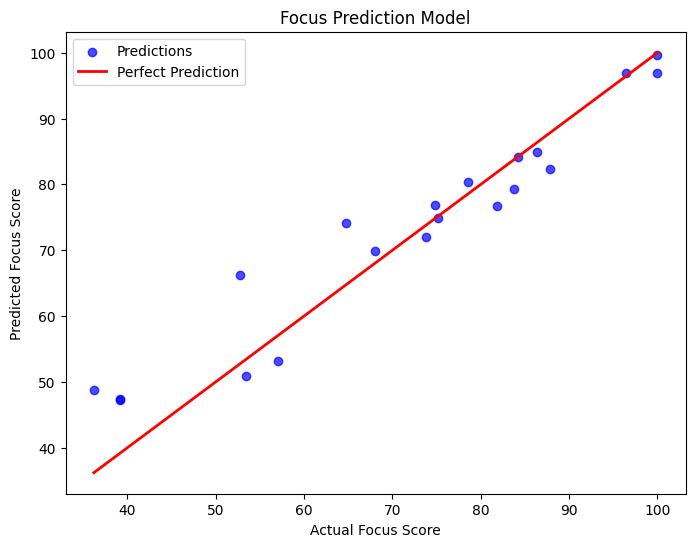

In [23]:
plt.figure(figsize=(8,6))

# scatter points (predictions)
plt.scatter(y_test, pred, color="blue", alpha=0.7, label="Predictions")

# ideal prediction line
min_val = min(y_test.min(), pred.min())
max_val = max(y_test.max(), pred.max())

plt.plot([min_val, max_val], [min_val, max_val], color="red", linewidth=2, label="Perfect Prediction")

plt.xlabel("Actual Focus Score")
plt.ylabel("Predicted Focus Score")
plt.title("Focus Prediction Model")

plt.legend()
plt.show()